In [1]:
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')
from data_loader import load_from_db

# Đọc VCB làm ví dụ
df = load_from_db('VCB', '2021-01-01', '2026-04-08')

# Kiểm tra cơ bản
print("Shape:", df.shape)
print("\nIndex:", df.index.dtype, "—", type(df.index[0]))
print("\nDtypes:")
print(df.dtypes)
print("\n5 dòng đầu:")
print(df.head())
print("\n5 dòng cuối:")
print(df.tail())

Shape: (1307, 5)

Index: datetime64[us] — <class 'pandas.Timestamp'>

Dtypes:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

5 dòng đầu:
             Open   High    Low  Close   Volume
Date                                           
2021-01-04  42.66  43.44  42.36  43.10   855900
2021-01-05  43.10  43.79  43.10  43.23   739200
2021-01-06  43.31  46.23  43.23  45.71  2080400
2021-01-07  45.27  47.23  45.27  46.58   889000
2021-01-08  47.01  47.01  45.49  45.62   963900

5 dòng cuối:
            Open  High   Low  Close   Volume
Date                                        
2026-03-30  57.9  58.5  57.8   58.0  5546000
2026-03-31  58.2  58.9  58.0   58.1  5481100
2026-04-01  58.9  59.2  58.5   59.0  8254700
2026-04-02  58.7  58.8  58.1   58.2  5664500
2026-04-03  58.3  58.5  57.7   57.7  5919600


In [2]:
# Kiểm tra index
print("=== INDEX ===")
print("Type  :", type(df.index))
print("Dtype :", df.index.dtype)
print("Min   :", df.index.min())
print("Max   :", df.index.max())
print("Freq  :", df.index.freq)  # None = không đều, bình thường với stock data

print("\n=== COLUMNS ===")
for col in df.columns:
    print(f"{col:8s} | dtype={df[col].dtype} | "
          f"min={df[col].min():.2f} | max={df[col].max():.2f} | "
          f"nulls={df[col].isnull().sum()}")

=== INDEX ===
Type  : <class 'pandas.DatetimeIndex'>
Dtype : datetime64[us]
Min   : 2021-01-04 00:00:00
Max   : 2026-04-03 00:00:00
Freq  : None

=== COLUMNS ===
Open     | dtype=float64 | min=35.42 | max=74.30 | nulls=0
High     | dtype=float64 | min=36.72 | max=78.80 | nulls=0
Low      | dtype=float64 | min=34.86 | max=73.10 | nulls=0
Close    | dtype=float64 | min=34.86 | max=76.00 | nulls=0
Volume   | dtype=int64 | min=175351.00 | max=32481400.00 | nulls=0


In [3]:
from data_loader import VN30_TICKERS

results = []
for ticker in VN30_TICKERS:
    d = load_from_db(ticker, '2021-01-01', '2026-04-08')
    results.append({
        'Ticker': ticker,
        'Rows'  : len(d),
        'Nulls' : d.isnull().sum().sum()
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
print(f"\nTổng nulls: {summary['Nulls'].sum()}")
print(f"Mã ít rows nhất: {summary.loc[summary['Rows'].idxmin(), 'Ticker']} "
      f"({summary['Rows'].min()} rows)")

Ticker  Rows  Nulls
   VCB  1307      0
   BID  1307      0
   CTG  1307      0
   TCB  1307      0
   MBB  1307      0
   VPB  1307      0
   ACB  1307      0
   HDB  1307      0
   STB  1307      0
   SHB  1304      0
   LPB  1307      0
   OCB  1289      0
   MSB  1307      0
   EIB  1307      0
   VIC  1307      0
   VHM  1307      0
   VRE  1307      0
   FPT  1307      0
   VNM  1307      0
   MWG  1307      0
   SAB  1307      0
   GAS  1307      0
   PLX  1307      0
   HPG  1307      0
   BVH  1307      0
   HVN  1307      0
   GMD  1307      0
   PDR  1307      0
   KDC  1307      0
   REE  1307      0

Tổng nulls: 0
Mã ít rows nhất: OCB (1289 rows)


=== MISSING DATES VCB ===
Ngày làm việc (B)  : 1374
Ngày trong DB      : 1307
Ngày thiếu (lễ/tết): 67

10 ngày thiếu đầu tiên:
  2021-01-01 Fri
  2021-02-10 Wed
  2021-02-11 Thu
  2021-02-12 Fri
  2021-02-15 Mon
  2021-02-16 Tue
  2021-04-21 Wed
  2021-04-30 Fri
  2021-05-03 Mon
  2021-09-02 Thu

=== ADJUSTED CLOSE CHECK ===
Ngày biến động >10% qua đêm: 0


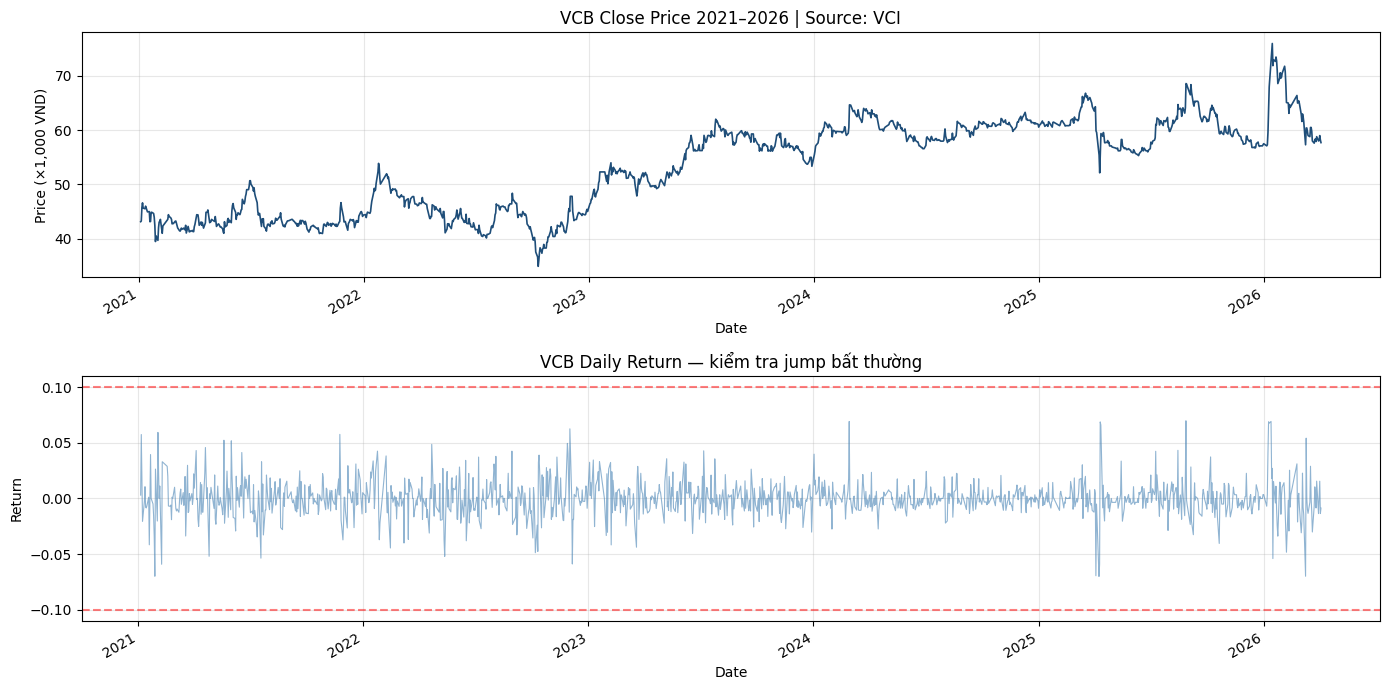

✅ Chart saved


In [4]:
import matplotlib.pyplot as plt

# ── Bước 4: missing dates ──────────────────────────────────────
full_range = pd.date_range(start='2021-01-01', end='2026-04-08', freq='B')
df_vcb = load_from_db('VCB', '2021-01-01', '2026-04-08')
missing_dates = full_range.difference(df_vcb.index)

print("=== MISSING DATES VCB ===")
print(f"Ngày làm việc (B)  : {len(full_range)}")
print(f"Ngày trong DB      : {len(df_vcb)}")
print(f"Ngày thiếu (lễ/tết): {len(missing_dates)}")
print(f"\n10 ngày thiếu đầu tiên:")
for d in missing_dates[:10]:
    print(f"  {d.strftime('%Y-%m-%d %a')}")

# ── Bước 7: kiểm tra Adjusted Close ───────────────────────────
overnight = df_vcb['Close'].pct_change()
big_moves = overnight[overnight.abs() > 0.1]

print(f"\n=== ADJUSTED CLOSE CHECK ===")
print(f"Ngày biến động >10% qua đêm: {len(big_moves)}")
if len(big_moves) > 0:
    print(big_moves.to_string())

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

df_vcb['Close'].plot(ax=axes[0], color='#1F4E79', linewidth=1.2)
axes[0].set_title('VCB Close Price 2021–2026 | Source: VCI')
axes[0].set_ylabel('Price (×1,000 VND)')
axes[0].grid(True, alpha=0.3)

overnight.plot(ax=axes[1], color='steelblue', alpha=0.6, linewidth=0.8)
axes[1].axhline(y=0.1,  color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('VCB Daily Return — kiểm tra jump bất thường')
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_data_quality_check.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [5]:
df_vcb = load_from_db('VCB', '2021-01-01', '2026-04-08')

simple_ret = df_vcb['Close'].pct_change()
log_ret = np.log(df_vcb['Close'] / df_vcb['Close'].shift(1))

print("=== 5 ngày đầu tiên ===")
comparison = pd.DataFrame({
    'Close'      : df_vcb['Close'],
    'Simple_ret' : simple_ret.round(6),
    'Log_ret'    : log_ret.round(6),
}).dropna().head(5)
print(comparison.to_string())

print(f"\nAnnualized Return (Simple) : {simple_ret.mean() * 252:.2%}")
print(f"Annualized Volatility      : {simple_ret.std() * np.sqrt(252):.2%}")

=== 5 ngày đầu tiên ===
            Close  Simple_ret   Log_ret
Date                                   
2021-01-05  43.23    0.003016  0.003012
2021-01-06  45.71    0.057368  0.055782
2021-01-07  46.58    0.019033  0.018854
2021-01-08  45.62   -0.020610 -0.020825
2021-01-11  45.49   -0.002850 -0.002854

Annualized Return (Simple) : 8.90%
Annualized Volatility      : 25.61%


In [6]:
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')

import importlib
import features
importlib.reload(features)
from features import calc_returns, annualized_return, annualized_volatility
from data_loader import load_from_db

df = load_from_db('VCB', '2021-01-01', '2026-04-08')
ret = calc_returns(df).dropna()

print(f"Rows           : {len(ret)}")
print(f"Ann. Return    : {annualized_return(ret):.2%}")
print(f"Ann. Volatility: {annualized_volatility(ret):.2%}")

Rows           : 1306
Ann. Return    : 8.90%
Ann. Volatility: 25.61%


In [7]:
from features import build_returns_matrix

matrix = build_returns_matrix(
    ['VCB', 'VNM', 'HPG', 'FPT', 'MWG'],
    '2021-01-01', '2026-04-08'
)
print("Shape  :", matrix.shape)
print("Columns:", matrix.columns.tolist())
print("Nulls  :", matrix.isnull().sum().sum())
print("\nSample:")
print(matrix.head(3).round(4))

Shape  : (1306, 5)
Columns: ['VCB', 'VNM', 'HPG', 'FPT', 'MWG']
Nulls  : 0

Sample:
               VCB     VNM     HPG     FPT     MWG
Date                                              
2021-01-05  0.0030  0.0231  0.0011  0.0415  0.0109
2021-01-06  0.0574 -0.0090  0.0106 -0.0048 -0.0051
2021-01-07  0.0190  0.0055  0.0000  0.0019 -0.0041


In [8]:
from features import ticker_stats

stats = ticker_stats('VCB', '2021-01-01', '2026-04-08')
print(f"VCB Ann Return    : {stats['ann_return']:.2%}")
print(f"VCB Ann Volatility: {stats['ann_volatility']:.2%}")
print(f"N days            : {stats['n_days']}")
print(f"\nVerify Return    : {'✅' if abs(stats['ann_return'] - 0.089) < 0.005 else '❌'}")
print(f"Verify Volatility: {'✅' if abs(stats['ann_volatility'] - 0.2561) < 0.005 else '❌'}")

VCB Ann Return    : 8.90%
VCB Ann Volatility: 25.61%
N days            : 1306

Verify Return    : ✅
Verify Volatility: ✅


In [9]:
from features import all_ticker_stats
from data_loader import VN30_TICKERS

stats = all_ticker_stats(VN30_TICKERS, '2021-01-01', '2026-04-08')
print(stats[['ticker','ann_return_pct','ann_volatility_pct','n_days']].to_string(index=False))
print(f"\nTrung bình Return    : {stats['ann_return_pct'].mean():.2f}%")
print(f"Trung bình Volatility: {stats['ann_volatility_pct'].mean():.2f}%")

ticker  ann_return_pct  ann_volatility_pct  n_days
   LPB           47.25               38.78    1306
   STB           31.68               39.23    1306
   HDB           28.07               32.43    1306
   MBB           27.67               31.53    1306
   VIC           27.58               36.94    1306
   GMD           26.88               35.87    1306
   FPT           24.28               28.67    1306
   SHB           22.89               39.03    1303
   REE           22.15               32.28    1306
   VPB           21.93               33.93    1306
   MWG           20.19               35.41    1306
   CTG           19.28               32.88    1306
   EIB           18.91               40.32    1306
   ACB           18.86               27.43    1306
   TCB           17.98               33.15    1306
   VHM           17.62               36.73    1306
   MSB           14.37               32.06    1306
   OCB           13.62               32.29    1288
   HPG           13.57         